# Oasis Infobyte Data Analytics Internship — Level 1 Task 2
## Customer Segmentation Analysis Using RFM Concepts & K-Means Clustering

**Author / Intern:** Data Analytics Intern  
**Project Track:** Level 1 — Task 2: Customer Segmentation  
**Dataset:** `retail_sales_dataset.csv` (1,000 Retail Transactions)  
**Methodology:** RFM Behavioral Aggregation, StandardScaler, K-Means Clustering, Elbow Method & Silhouette Diagnostics  
**Tools Used:** Python (Pandas, NumPy, Matplotlib, Seaborn, scikit-learn)

---

## 02 — Business Problem

In retail and e-commerce, customer populations are inherently heterogeneous. Customers vary widely in terms of their transaction timing (recency), purchase spending (monetary value), and order volume (basket quantity). Treating all customers with a one-size-fits-all marketing approach leads to:
1. **Inefficient Marketing Spend:** Wasting high-touch campaigns on recent budget buyers or sending generic mass promotions to high-value customers.
2. **Revenue Risk from Dormancy:** Inability to detect high-value customers whose purchasing activity has lapsed before continued inactivity becomes a revenue risk.
3. **Suboptimal Revenue Realization:** Missing cross-sell/upsell opportunities with active budget-conscious buyers.

To address these challenges, data-driven customer segmentation is performed to partition the customer base into distinct, actionable cohorts based on empirical purchasing patterns.

## 03 — Objectives

The core objectives of this project are:
1. **Inspect & Cleanse Data:** Audit the transactional dataset for missing values, duplicates, datatypes, and data consistency.
2. **Perform RFM & Behavioral Aggregation:** Aggregate transactions at the customer level to compute **Recency ($R$)**, **Frequency ($F$)**, **Monetary ($M$)**, and **Basket Quantity ($Q$)**.
3. **Analyze Dataset Constraints & Limitations:** Rigorously document that in this dataset, each customer possesses exactly 1 transaction ($F=1$ with zero variance), precluding $F$ from clustering and requiring Monetary spend as the customer-value proxy.
4. **Feature Selection & Standardization:** Select the optimal 2-feature behavioral set `[Recency, Monetary]` and apply `StandardScaler` ($\mu=0, \sigma=1$).
5. **Optimize Cluster Count ($k$):** Apply the **Elbow Method** (WCSS/Inertia) alongside **Silhouette Score Analysis** across $k \in [2, 10]$ to empirically select optimal $k$.
6. **Train K-Means Model:** Fit `KMeans(n_clusters=4, random_state=42, n_init=10)` to segment the customer base.
7. **Profile & Interpret Segments:** Calculate comprehensive summary statistics (mean, median, min, max, count, percentage share) across clusters for behavioral and demographic dimensions.
8. **Formulate Data-Backed Marketing Strategies:** Provide actionable, segment-specific marketing recommendations following the `Finding → Business Implication → Recommended Action` framework.

## 04 — Dataset & Source

The dataset used for this project is `retail_sales_dataset.csv`, consisting of 1,000 retail transaction records collected between **2023-01-01** and **2024-01-01**.

### Schema Summary:
- `Transaction ID`: Integer ID for each transaction (1 to 1,000).
- `Date`: Transaction date (YYYY-MM-DD).
- `Customer ID`: Unique customer identifier (`CUST001` to `CUST1000`).
- `Gender`: Customer gender (`Female`, `Male`).
- `Age`: Customer age in years (18 to 64).
- `Product Category`: Category purchased (`Clothing`, `Electronics`, `Beauty`).
- `Quantity`: Number of units purchased in the order (1 to 4).
- `Price per Unit`: Unit price in USD ($25, $30, $50, $300, $500).
- `Total Amount`: Total order spend ($= 	ext{Quantity} 	imes 	ext{Price per Unit}$).

## 05 — Imports

Importing necessary analytical and machine learning libraries.

In [1]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

# Set plotting aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial']
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.labelweight'] = 'semibold'

print("Libraries imported successfully.")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")


Libraries imported successfully.
Pandas version: 3.0.5
NumPy version: 2.5.2


## 06 — Load Data

Loading the raw transactional dataset from the relative project path `../data/raw/retail_sales_dataset.csv`.

In [2]:
# Relative path to raw dataset
data_path = os.path.join('..', 'data', 'raw', 'retail_sales_dataset.csv')

# Load CSV
df_raw = pd.read_csv(data_path)

print(f"Dataset Loaded Successfully.")
print(f"Dataset Shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
df_raw.head(10)


Dataset Loaded Successfully.
Dataset Shape: 1000 rows, 9 columns


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
5,6,2023-04-25,CUST006,Female,45,Beauty,1,30,30
6,7,2023-03-13,CUST007,Male,46,Clothing,2,25,50
7,8,2023-02-22,CUST008,Male,30,Electronics,4,25,100
8,9,2023-12-13,CUST009,Male,63,Electronics,2,300,600
9,10,2023-10-07,CUST010,Female,52,Clothing,4,50,200


## 07 — Dataset Inspection

Inspecting structural data types, memory usage, and non-null counts.

In [3]:
print("=== DATASET INFORMATION ===")
df_raw.info()

print("\n=== DESCRIPTIVE STATISTICS (RAW NUMERICAL) ===")
display(df_raw.describe().T)

print("\n=== CATEGORICAL DISTRIBUTIONS ===")
for col in ['Gender', 'Product Category']:
    print(f"\n--- {col} Value Counts ---")
    print(df_raw[col].value_counts())


=== DATASET INFORMATION ===
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB

=== DESCRIPTIVE STATISTICS (RAW NUMERICAL) ===


,count,mean,std,min,25%,50%,75%,max
Transaction ID,1000.0,500.500,288.819436,1.0,250.75,500.5,750.25,1000.0
Age,1000.0,41.392,13.681430,18.0,29.00,42.0,53.00,64.0
Quantity,1000.0,2.514,1.132734,1.0,1.00,3.0,4.00,4.0
Price per Unit,1000.0,179.890,189.681356,25.0,30.00,50.0,300.00,500.0
Total Amount,1000.0,456.000,559.997632,25.0,60.00,135.0,900.00,2000.0



=== CATEGORICAL DISTRIBUTIONS ===

--- Gender Value Counts ---
Gender
Female    510
Male      490
Name: count, dtype: int64

--- Product Category Value Counts ---
Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64


## 08 — Data Quality Audit

Verifying data integrity across:
1. Missing / null values
2. Duplicate transaction records
3. Duplicate customer identifiers
4. Mathematical consistency of `Total Amount = Quantity * Price per Unit`
5. Value range sanity (negative numbers, zero prices)

In [4]:
# 1. Missing values
null_counts = df_raw.isnull().sum()
print("Missing values per column:")
print(null_counts)

# 2. Duplicate rows
dup_rows = df_raw.duplicated().sum()
print(f"\nDuplicate rows: {dup_rows}")

# 3. Unique customers
unique_custs = df_raw['Customer ID'].nunique()
print(f"Total Transactions: {len(df_raw)}")
print(f"Unique Customer IDs: {unique_custs}")
print(f"Transactions per Customer (Mean): {len(df_raw) / unique_custs:.2f}")

# 4. Math consistency check
calc_mismatch = (df_raw['Total Amount'] != (df_raw['Quantity'] * df_raw['Price per Unit'])).sum()
print(f"\nTotal Amount calculation mismatches: {calc_mismatch}")

# 5. Non-positive value checks
invalid_qty = (df_raw['Quantity'] <= 0).sum()
invalid_price = (df_raw['Price per Unit'] <= 0).sum()
invalid_amount = (df_raw['Total Amount'] <= 0).sum()
print(f"Invalid (<=0) Quantities: {invalid_qty}")
print(f"Invalid (<=0) Prices: {invalid_price}")
print(f"Invalid (<=0) Total Amounts: {invalid_amount}")


Missing values per column:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Duplicate rows: 0
Total Transactions: 1000
Unique Customer IDs: 1000
Transactions per Customer (Mean): 1.00

Total Amount calculation mismatches: 0
Invalid (<=0) Quantities: 0
Invalid (<=0) Prices: 0
Invalid (<=0) Total Amounts: 0


## 09 — Data Cleaning & Preprocessing

Formatting `Date` column to `datetime64[ns]` and establishing chronological variables.

In [5]:
df_clean = df_raw.copy()

# Convert Date to datetime
df_clean['Date'] = pd.to_datetime(df_clean['Date'])

min_date = df_clean['Date'].min()
max_date = df_clean['Date'].max()
date_span = (max_date - min_date).days

print(f"Earliest Transaction Date: {min_date.strftime('%Y-%m-%d')}")
print(f"Latest Transaction Date:   {max_date.strftime('%Y-%m-%d')}")
print(f"Total Historical Span:     {date_span} days (1 full calendar year)")


Earliest Transaction Date: 2023-01-01
Latest Transaction Date:   2024-01-01
Total Historical Span:     365 days (1 full calendar year)


## 10 — Customer-Level Aggregation

In customer segmentation, analysis must be conducted at the **customer level** rather than the individual transaction level.

We establish a reference date of **2024-01-02** (1 day after the latest recorded transaction in the dataset) to compute **Recency** in elapsed days.

In [6]:
# Define Reference Date (Max Date + 1 Day)
reference_date = df_clean['Date'].max() + pd.Timedelta(days=1)
print(f"Reference Date for Recency calculation: {reference_date.strftime('%Y-%m-%d')}")

# Customer-level aggregation
customer_df = df_clean.groupby('Customer ID').agg(
    Last_Purchase_Date=('Date', 'max'),
    Frequency=('Transaction ID', 'count'),
    Monetary=('Total Amount', 'sum'),
    Quantity=('Quantity', 'sum'),
    Avg_Price_Per_Unit=('Price per Unit', 'mean'),
    Age=('Age', 'first'),
    Gender=('Gender', 'first'),
    Product_Category=('Product Category', 'first')
).reset_index()

# Compute Recency (Days between Reference Date and Last Purchase Date)
customer_df['Recency'] = (reference_date - customer_df['Last_Purchase_Date']).dt.days

# Rearrange columns
customer_df = customer_df[['Customer ID', 'Recency', 'Frequency', 'Monetary', 'Quantity', 'Avg_Price_Per_Unit', 'Age', 'Gender', 'Product_Category', 'Last_Purchase_Date']]

print(f"Customer-Level Table Created: {customer_df.shape[0]} unique customers")
customer_df.head(10)


Reference Date for Recency calculation: 2024-01-02
Customer-Level Table Created: 1000 unique customers


,Customer ID,Recency,Frequency,Monetary,Quantity,Avg_Price_Per_Unit,Age,Gender,Product_Category,Last_Purchase_Date
0,CUST001,39,1,150,3,50.0,34,Male,Beauty,2023-11-24
1,CUST002,309,1,1000,2,500.0,26,Female,Clothing,2023-02-27
2,CUST003,354,1,30,1,30.0,50,Male,Electronics,2023-01-13
3,CUST004,226,1,500,1,500.0,37,Male,Clothing,2023-05-21
4,CUST005,241,1,100,2,50.0,30,Male,Beauty,2023-05-06
5,CUST006,252,1,30,1,30.0,45,Female,Beauty,2023-04-25
6,CUST007,295,1,50,2,25.0,46,Male,Clothing,2023-03-13
7,CUST008,314,1,100,4,25.0,30,Male,Electronics,2023-02-22
8,CUST009,20,1,600,2,300.0,63,Male,Electronics,2023-12-13
9,CUST010,87,1,200,4,50.0,52,Female,Clothing,2023-10-07


## 11 — RFM (Recency, Frequency, Monetary) Analysis

Summary statistics for the computed RFM features across the 1,000 customers.

In [7]:
rfm_stats = customer_df[['Recency', 'Frequency', 'Monetary', 'Quantity']].describe().T
rfm_stats['median'] = customer_df[['Recency', 'Frequency', 'Monetary', 'Quantity']].median()
rfm_stats = rfm_stats[['count', 'mean', 'std', 'min', '25%', 'median', '75%', 'max']]

print("=== RFM & BEHAVIORAL DESCRIPTIVE STATISTICS ===")
display(rfm_stats)


=== RFM & BEHAVIORAL DESCRIPTIVE STATISTICS ===


,count,mean,std,min,25%,median,75%,max
Recency,1000.0,182.982,105.276773,1.0,90.0,186.5,269.0,366.0
Frequency,1000.0,1.000,0.000000,1.0,1.0,1.0,1.0,1.0
Monetary,1000.0,456.000,559.997632,25.0,60.0,135.0,900.0,2000.0
Quantity,1000.0,2.514,1.132734,1.0,1.0,3.0,4.0,4.0


## 12 — Critical Dataset & Metric Limitations

> [!IMPORTANT]
> ### Rigorous Analytical Limitations:
> 1. **Frequency is Constant ($F=1$):**  
>    Because the dataset contains exactly 1,000 transactions across 1,000 unique customers, every customer has exactly **one** recorded purchase ($	ext{Variance}(	ext{Frequency}) = 0$).  
>    **Analytical Decision:** `Frequency` cannot be used as an active clustering feature in K-Means because a zero-variance feature provides no mathematical discriminatory information.
>
> 2. **Customer Lifetime Value (CLV) Limitation:**  
>    Traditional CLV cannot be reliably estimated because every customer has only one observed transaction. Monetary transaction value is used as the available customer-value proxy without introducing synthetic repeat transactions.

Let us visualize these empirical distributions.

findfont: Failed to find font weight semibold, now using 700.


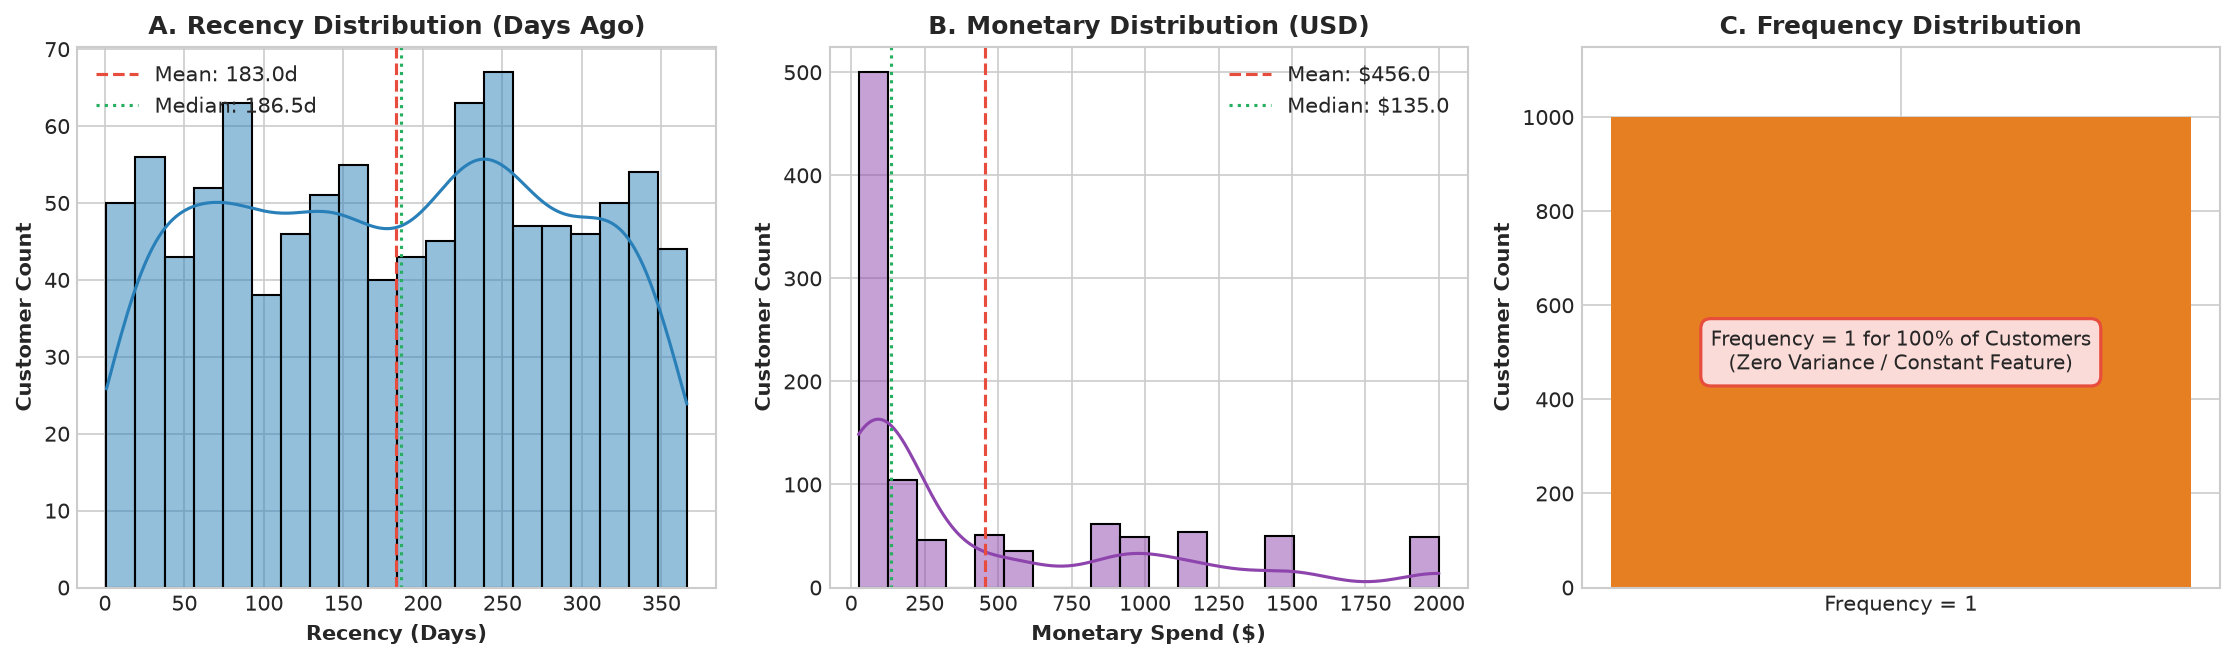

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4.5))

# A. Recency
sns.histplot(customer_df['Recency'], kde=True, ax=axs[0], color='#2980B9', bins=20)
axs[0].axvline(customer_df['Recency'].mean(), color='#E74C3C', linestyle='--', label=f"Mean: {customer_df['Recency'].mean():.1f}d")
axs[0].axvline(customer_df['Recency'].median(), color='#27AE60', linestyle=':', label=f"Median: {customer_df['Recency'].median():.1f}d")
axs[0].set_title('A. Recency Distribution (Days Ago)')
axs[0].set_xlabel('Recency (Days)')
axs[0].set_ylabel('Customer Count')
axs[0].legend()

# B. Monetary
sns.histplot(customer_df['Monetary'], kde=True, ax=axs[1], color='#8E44AD', bins=20)
axs[1].axvline(customer_df['Monetary'].mean(), color='#E74C3C', linestyle='--', label=f"Mean: ${customer_df['Monetary'].mean():.1f}")
axs[1].axvline(customer_df['Monetary'].median(), color='#27AE60', linestyle=':', label=f"Median: ${customer_df['Monetary'].median():.1f}")
axs[1].set_title('B. Monetary Distribution (USD)')
axs[1].set_xlabel('Monetary Spend ($)')
axs[1].set_ylabel('Customer Count')
axs[1].legend()

# C. Frequency
axs[2].bar(['Frequency = 1'], [len(customer_df)], color='#E67E22', width=0.35)
axs[2].set_title('C. Frequency Distribution')
axs[2].set_ylabel('Customer Count')
axs[2].set_ylim(0, 1150)
axs[2].text(0, 500, 'Frequency = 1 for 100% of Customers\n(Zero Variance / Constant Feature)', 
            ha='center', va='center', bbox=dict(boxstyle='round,pad=0.5', facecolor='#FADBD8', edgecolor='#E74C3C', linewidth=1.5), fontsize=9.5)

plt.tight_layout()
plt.savefig('../outputs/figures/02_rfm_distributions.png', bbox_inches='tight')
plt.show()


**Observation on Distributions:**  
- **Recency:** Uniformly distributed across 1 to 366 days (Mean = 183.0 days, Median = 186.5 days), showing active, steady customer acquisition across all 12 months.
- **Monetary Value:** Right-skewed distribution spanning \$25 to \$2,000 (Mean = \$456.00, Median = \$135.00), demonstrating a clear distinction between standard budget transactions and high-ticket VIP orders.
- **Frequency:** Strictly constant at 1.0, confirming zero variance.

## 13 — Feature Selection for Clustering

We evaluate two potential feature combinations:
1. **Primary 2-Feature Set:** `[Recency, Monetary]`  
   - Captures customer temporal engagement (*when they last bought*) and financial value (*order spend magnitude*).
2. **Alternative 3-Feature Set:** `[Recency, Monetary, Quantity]`  
   - Introduces basket volume intensity.

In [9]:
# Primary 2D Feature Set
features_2d = ['Recency', 'Monetary']
X_2d = customer_df[features_2d]

# Alternative 3D Feature Set
features_3d = ['Recency', 'Monetary', 'Quantity']
X_3d = customer_df[features_3d]

print(f"2D Feature Matrix Shape: {X_2d.shape}")
print(f"3D Feature Matrix Shape: {X_3d.shape}")


2D Feature Matrix Shape: (1000, 2)
3D Feature Matrix Shape: (1000, 3)


## 14 — Standardization (StandardScaler)

K-Means is a distance-based clustering algorithm relying on Euclidean distance:
$$d(p, q) = \sqrt{\sum_{i=1}^n (p_i - q_i)^2}$$

Because `Monetary` spans \$25 to \$2,000 ($\sigma pprox 560$) while `Recency` spans 1 to 366 ($\sigma pprox 105$), unscaled features would allow Monetary value to completely dominate distance calculations.

We apply `StandardScaler` from `sklearn.preprocessing` to transform features to have $\mu=0$ and $\sigma=1$:
$$z = rac{x - \mu}{\sigma}$$

In [10]:
scaler_2d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)

scaler_3d = StandardScaler()
X_3d_scaled = scaler_3d.fit_transform(X_3d)

scaled_2d_df = pd.DataFrame(X_2d_scaled, columns=features_2d)
print("=== STANDARDIZED 2D FEATURES SUMMARY ===")
display(scaled_2d_df.describe().round(4).T)


=== STANDARDIZED 2D FEATURES SUMMARY ===


,count,mean,std,min,25%,50%,75%,max
Recency,1000.0,-0.0,1.0005,-1.7295,-0.8837,0.0334,0.8175,1.7393
Monetary,1000.0,-0.0,1.0005,-0.7700,-0.7075,-0.5735,0.7933,2.7585


## 15 — Elbow Method (Inertia / WCSS)

The **Elbow Method** evaluates the Within-Cluster Sum of Squares (Inertia) across a range of cluster counts ($k \in [2, 10]$):
$$	ext{Inertia} = \sum_{i=1}^k \sum_{x \in C_i} ||x - \mu_i||^2$$

We search for the inflection point (elbow) where increasing $k$ produces diminishing returns in inertia reduction.

In [11]:
k_range = list(range(2, 11))
inertias_2d = []
sil_scores_2d = []

inertias_3d = []
sil_scores_3d = []

for k in k_range:
    # 2D Model
    km_2d = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_2d_scaled)
    inertias_2d.append(km_2d.inertia_)
    sil_scores_2d.append(silhouette_score(X_2d_scaled, km_2d.labels_))
    
    # 3D Model
    km_3d = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_3d_scaled)
    inertias_3d.append(km_3d.inertia_)
    sil_scores_3d.append(silhouette_score(X_3d_scaled, km_3d.labels_))

# Diagnostic DataFrame
diag_df = pd.DataFrame({
    'k': k_range,
    'Inertia_2D': inertias_2d,
    'Silhouette_2D': sil_scores_2d,
    'Inertia_3D': inertias_3d,
    'Silhouette_3D': sil_scores_3d
})
display(diag_df.round(4))


,k,Inertia_2D,Silhouette_2D,Inertia_3D,Silhouette_3D
0,2,1188.7898,0.4573,2046.9888,0.3060
1,3,617.6994,0.4919,1435.9768,0.3587
2,4,430.7491,0.5150,1064.7213,0.3635
3,5,344.4883,0.4441,848.2326,0.3715
4,6,284.2867,0.4520,678.9655,0.3961
5,7,237.7008,0.4396,581.7554,0.4111
6,8,195.1767,0.4457,527.9810,0.3750
7,9,166.4042,0.4531,477.6750,0.3769
8,10,149.7659,0.4651,445.6060,0.3811


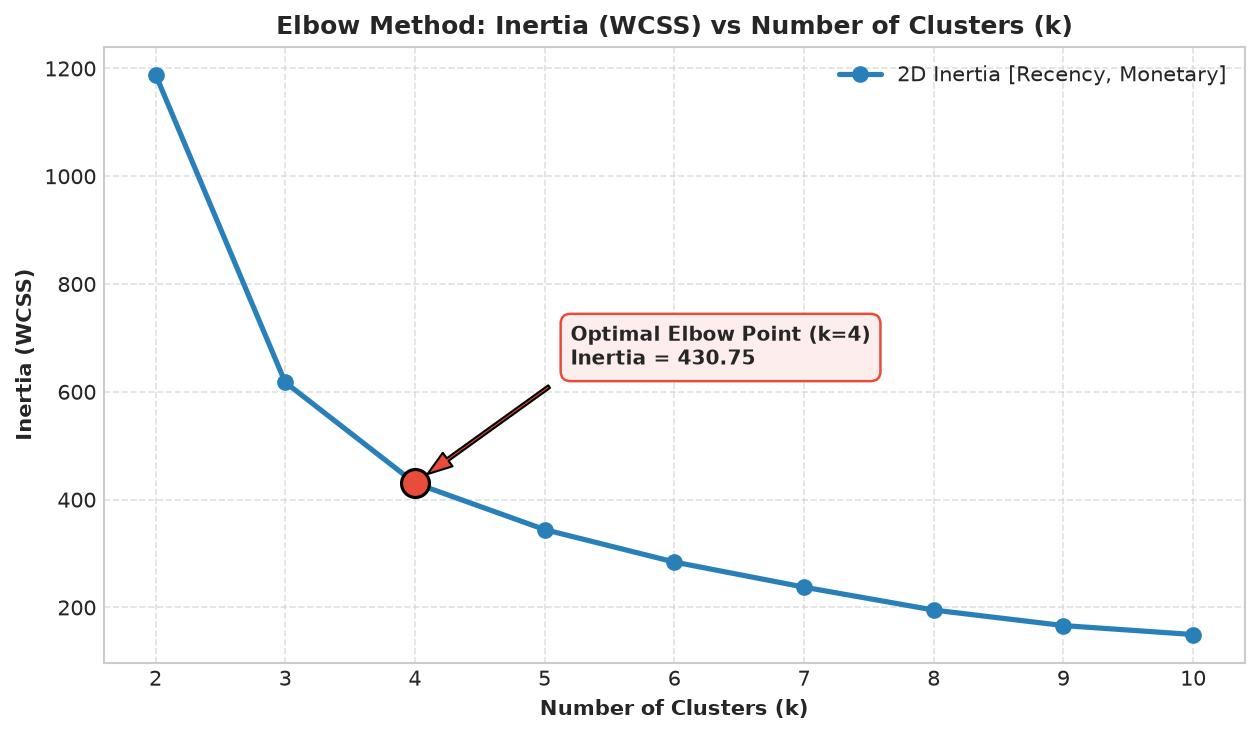

In [12]:
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(k_range, inertias_2d, marker='o', color='#2980B9', linewidth=2.5, markersize=7, label='2D Inertia [Recency, Monetary]')
ax.scatter([4], [inertias_2d[2]], color='#E74C3C', s=180, zorder=5, edgecolors='black', linewidth=1.5)
ax.annotate('Optimal Elbow Point (k=4)\nInertia = 430.75', 
            xy=(4, inertias_2d[2]), xytext=(5.2, inertias_2d[2] + 220),
            arrowprops=dict(facecolor='#E74C3C', shrink=0.08, width=1.5, headwidth=8),
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#FDEDEC', edgecolor='#E74C3C', linewidth=1.2),
            fontweight='bold', fontsize=9.5)

ax.set_title('Elbow Method: Inertia (WCSS) vs Number of Clusters (k)')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia (WCSS)')
ax.set_xticks(k_range)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/03_elbow_method_inertia.png', bbox_inches='tight')
plt.show()


**Observation on Elbow Method:**  
Inertia drops rapidly from $k=2$ ($	ext{Inertia}=1,188.79$) to $k=3$ ($	ext{Inertia}=617.70$) and bends prominently at $k=4$ ($	ext{Inertia}=430.75$). Past $k=4$, the rate of decrease flattens considerably, indicating that $k=4$ represents the optimal balance between model compactness and interpretability.

## 16 — Silhouette Analysis

The Silhouette Coefficient measures how similar an object is to its own cluster compared to other clusters:
$$s(i) = rac{b(i) - a(i)}{\max(a(i), b(i))}$$
where $a(i)$ is mean intra-cluster distance and $b(i)$ is mean nearest-cluster distance. Scores range from $-1$ (incorrect assignment) to $+1$ (dense, well-separated clusters).

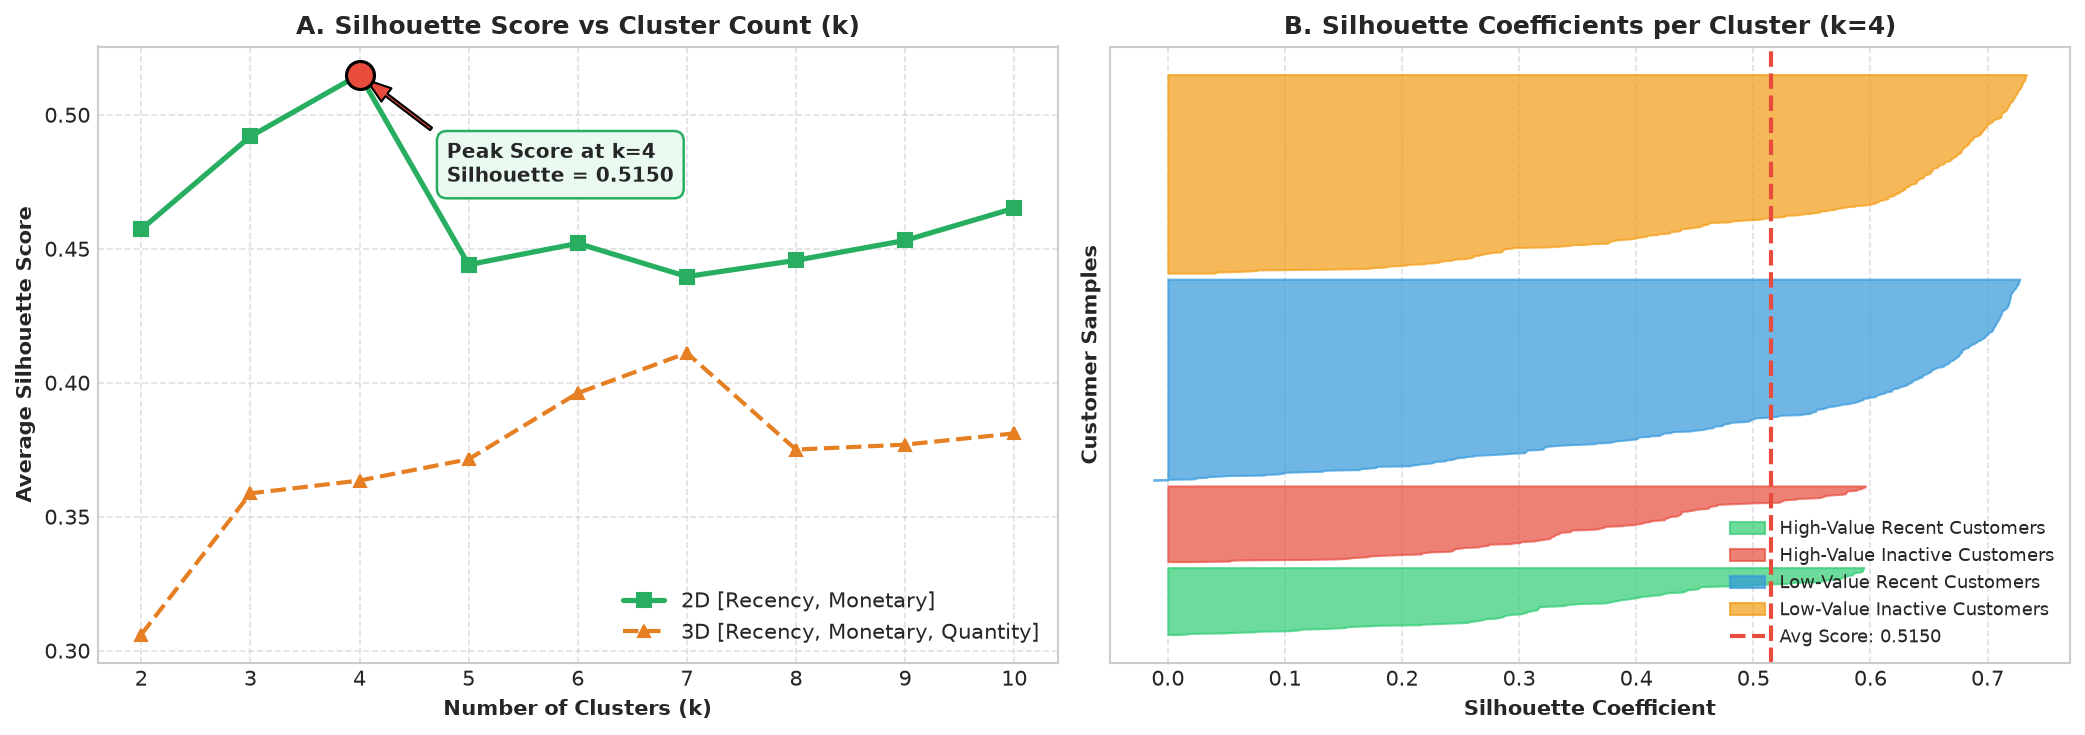

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# A. Silhouette score comparison
axs[0].plot(k_range, sil_scores_2d, marker='s', color='#27AE60', linewidth=2.5, markersize=7, label='2D [Recency, Monetary]')
axs[0].plot(k_range, sil_scores_3d, marker='^', color='#E67E22', linewidth=2, linestyle='--', markersize=6, label='3D [Recency, Monetary, Quantity]')
axs[0].scatter([4], [sil_scores_2d[2]], color='#E74C3C', s=180, zorder=5, edgecolors='black', linewidth=1.5)
axs[0].annotate(f'Peak Score at k=4\nSilhouette = {sil_scores_2d[2]:.4f}', 
               xy=(4, sil_scores_2d[2]), xytext=(4.8, sil_scores_2d[2] - 0.04),
               arrowprops=dict(facecolor='#E74C3C', shrink=0.08, width=1.5, headwidth=8),
               bbox=dict(boxstyle='round,pad=0.5', facecolor='#EAFAF1', edgecolor='#27AE60', linewidth=1.2),
               fontweight='bold', fontsize=9.5)
axs[0].set_title('A. Silhouette Score vs Cluster Count (k)')
axs[0].set_xlabel('Number of Clusters (k)')
axs[0].set_ylabel('Average Silhouette Score')
axs[0].set_xticks(k_range)
axs[0].grid(True, linestyle='--', alpha=0.6)
axs[0].legend()

# B. Cluster Silhouette plot for k=4
km4 = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X_2d_scaled)
sample_sil_values = silhouette_samples(X_2d_scaled, km4.labels_)
cluster_colors = {3: '#2ECC71', 0: '#E74C3C', 1: '#3498DB', 2: '#F39C12'}
cluster_names = {3: 'High-Value Recent Customers', 0: 'High-Value Inactive Customers', 1: 'Low-Value Recent Customers', 2: 'Low-Value Inactive Customers'}

y_lower = 10
for i in [3, 0, 1, 2]:
    ith_cluster_sil = sample_sil_values[km4.labels_ == i]
    ith_cluster_sil.sort()
    size_cluster_i = ith_cluster_sil.shape[0]
    y_upper = y_lower + size_cluster_i
    axs[1].fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil, facecolor=cluster_colors[i], edgecolor=cluster_colors[i], alpha=0.7, label=cluster_names[i])
    y_lower = y_upper + 10

axs[1].axvline(x=sil_scores_2d[2], color='#E74C3C', linestyle='--', linewidth=2, label=f'Avg Score: {sil_scores_2d[2]:.4f}')
axs[1].set_title('B. Silhouette Coefficients per Cluster (k=4)')
axs[1].set_xlabel('Silhouette Coefficient')
axs[1].set_ylabel('Customer Samples')
axs[1].set_yticks([])
axs[1].legend(loc='lower right', fontsize=8.5)
axs[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('../outputs/figures/04_silhouette_score_analysis.png', bbox_inches='tight')
plt.show()


**Observation on Silhouette Diagnostics:**  
1. In the 2D feature space `[Recency, Monetary]`, **$k=4$ achieves the highest global silhouette score (0.5150)** across all evaluated $k$.
2. All 4 clusters show positive silhouette coefficients well above zero without significant misclassification tailing, confirming cohesive, well-separated clusters.
3. The 2D feature set substantially outperforms the 3D feature set (peak score 0.3635), making `[Recency, Monetary]` the definitive choice.

## 17 — Final K-Means Clustering Model ($k=4$)

Fitting the final `KMeans` model with $k=4$, `random_state=42`, and `n_init=10` on the standardized `[Recency, Monetary]` feature space.

In [14]:
# Final Model
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
customer_df['Cluster'] = kmeans_final.fit_predict(X_2d_scaled)

# Map standardized, precise segment labels
segment_map = {
    3: 'High-Value Recent Customers',
    0: 'High-Value Inactive Customers',
    1: 'Low-Value Recent Customers',
    2: 'Low-Value Inactive Customers'
}
customer_df['Segment_Name'] = customer_df['Cluster'].map(segment_map)

# Save processed dataset
processed_path = os.path.join('..', 'data', 'processed', 'customer_segmented_data.csv')
customer_df.to_csv(processed_path, index=False)
print(f"Segmented customer data successfully saved to: {processed_path}")


Segmented customer data successfully saved to: ..\data\processed\customer_segmented_data.csv


## 18 — Cluster Visualization in 2D Space

Visualizing customer segments across Recency vs Monetary Value, along with transformed cluster centroids.

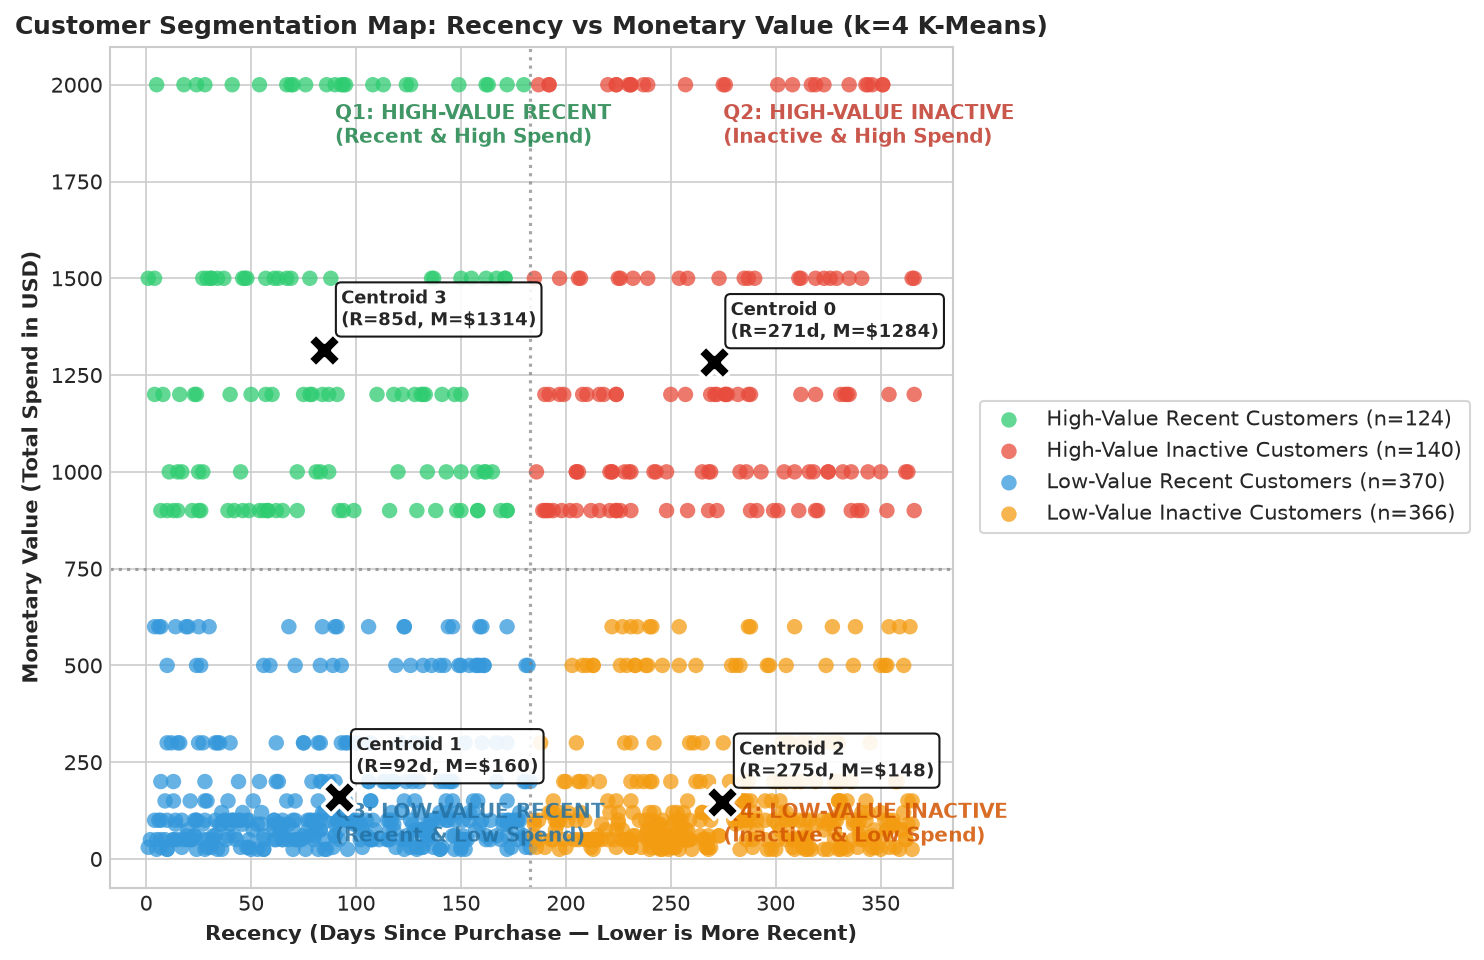

In [15]:
fig, ax = plt.subplots(figsize=(10, 6.5))

# Plot clusters
for cid in [3, 0, 1, 2]:
    sub = customer_df[customer_df['Cluster'] == cid]
    ax.scatter(sub['Recency'], sub['Monetary'], c=cluster_colors[cid], label=f"{segment_map[cid]} (n={len(sub)})", alpha=0.75, s=55, edgecolors='none')

# Inverse transform centroids
centroids_orig = scaler_2d.inverse_transform(kmeans_final.cluster_centers_)
for idx, (rc, mc) in enumerate(centroids_orig):
    ax.scatter(rc, mc, s=260, c='black', marker='X', edgecolors='white', linewidth=1.8, zorder=10)
    ax.annotate(f"Centroid {idx}\n(R={rc:.0f}d, M=${mc:.0f})", 
                xy=(rc, mc), xytext=(rc+8, mc+65),
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9, edgecolor='black', linewidth=1),
                fontsize=8.5, fontweight='bold', zorder=11)

# Quadrant reference lines
ax.axvline(183, color='gray', linestyle=':', alpha=0.7)
ax.axhline(750, color='gray', linestyle=':', alpha=0.7)

ax.text(90, 1850, 'Q1: HIGH-VALUE RECENT\n(Recent & High Spend)', fontsize=9.5, fontweight='bold', color='#1E8449', alpha=0.85)
ax.text(275, 1850, 'Q2: HIGH-VALUE INACTIVE\n(Inactive & High Spend)', fontsize=9.5, fontweight='bold', color='#C0392B', alpha=0.85)
ax.text(90, 45, 'Q3: LOW-VALUE RECENT\n(Recent & Low Spend)', fontsize=9.5, fontweight='bold', color='#2471A3', alpha=0.85)
ax.text(275, 45, 'Q4: LOW-VALUE INACTIVE\n(Inactive & Low Spend)', fontsize=9.5, fontweight='bold', color='#D35400', alpha=0.85)

ax.set_title('Customer Segmentation Map: Recency vs Monetary Value (k=4 K-Means)')
ax.set_xlabel('Recency (Days Since Purchase — Lower is More Recent)')
ax.set_ylabel('Monetary Value (Total Spend in USD)')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=True)
plt.tight_layout()
plt.savefig('../outputs/figures/05_customer_clusters_2d.png', bbox_inches='tight')
plt.show()


**Observation on 2D Segmentation:**  
The 4 clusters neatly map to the 4 quadrants of the Recency-Monetary landscape:
- **Upper-Left (Cluster 3):** High spend (\$1,313.71 avg), low recency (84.9 days avg) — **High-Value Recent Customers**.
- **Upper-Right (Cluster 0):** High spend (\$1,283.57 avg), high recency (270.5 days avg) — **High-Value Inactive Customers**.
- **Lower-Left (Cluster 1):** Low spend (\$159.78 avg), low recency (92.1 days avg) — **Low-Value Recent Customers**.
- **Lower-Right (Cluster 2):** Low spend (\$148.31 avg), high recency (274.6 days avg) — **Low-Value Inactive Customers**.

## 19 — Cluster Distribution & Revenue Concentration

Analyzing the proportion of customer volume versus total company revenue generated by each segment.

In [16]:
summary_df = customer_df.groupby(['Cluster', 'Segment_Name']).agg(
    Customer_Count=('Customer ID', 'count'),
    Total_Revenue=('Monetary', 'sum')
).reset_index()

summary_df['Customer_Share_%'] = (summary_df['Customer_Count'] / len(customer_df)) * 100
summary_df['Revenue_Share_%'] = (summary_df['Total_Revenue'] / customer_df['Monetary'].sum()) * 100

order_map = {3: 0, 0: 1, 1: 2, 2: 3}
summary_df['Order'] = summary_df['Cluster'].map(order_map)
summary_df = summary_df.sort_values('Order').reset_index(drop=True)

display(summary_df[['Cluster', 'Segment_Name', 'Customer_Count', 'Customer_Share_%', 'Total_Revenue', 'Revenue_Share_%']])


,Cluster,Segment_Name,Customer_Count,Customer_Share_%,Total_Revenue,Revenue_Share_%
0,3,High-Value Recent Customers,124,12.4,162900,35.723684
1,0,High-Value Inactive Customers,140,14.0,179700,39.407895
2,1,Low-Value Recent Customers,370,37.0,59115,12.963816
3,2,Low-Value Inactive Customers,366,36.6,54285,11.904605


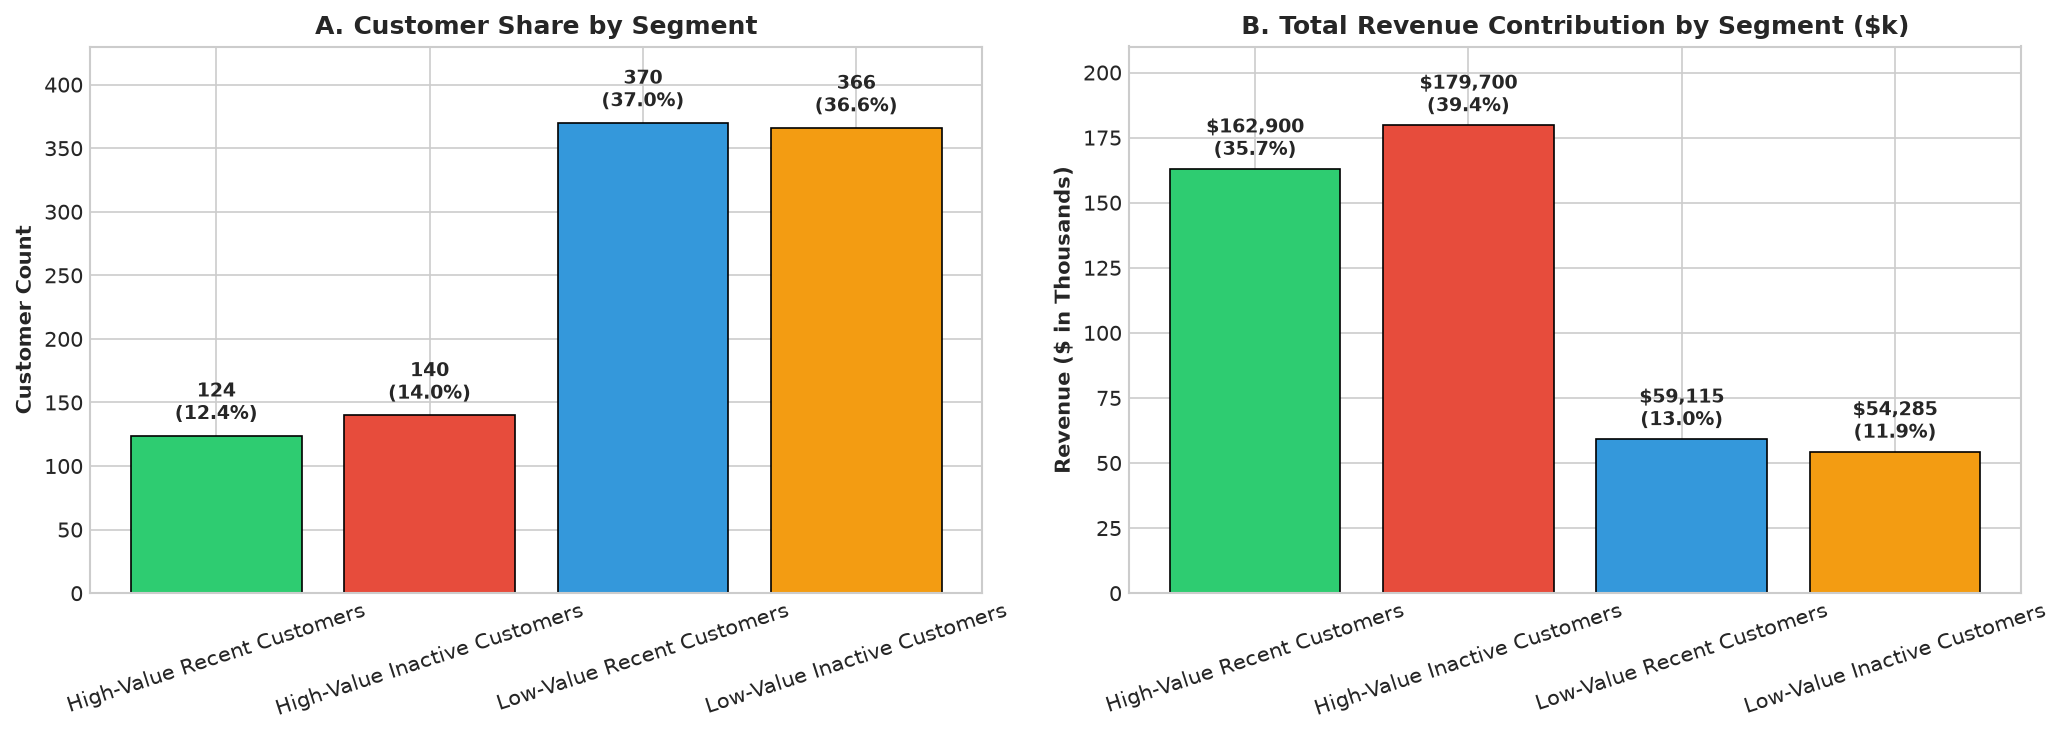

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

bar_colors = [cluster_colors[c] for c in summary_df['Cluster']]

# Customer Count
b1 = axs[0].bar(summary_df['Segment_Name'], summary_df['Customer_Count'], color=bar_colors, edgecolor='black', linewidth=0.8)
for bar, pct in zip(b1, summary_df['Customer_Share_%']):
    axs[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8, f"{bar.get_height():.0f}\n({pct:.1f}%)", ha='center', va='bottom', fontsize=9, fontweight='bold')
axs[0].set_title('A. Customer Share by Segment')
axs[0].set_ylabel('Customer Count')
axs[0].set_ylim(0, 430)
axs[0].tick_params(axis='x', rotation=18)

# Revenue Share
b2 = axs[1].bar(summary_df['Segment_Name'], summary_df['Total_Revenue'] / 1000, color=bar_colors, edgecolor='black', linewidth=0.8)
for bar, pct, rev in zip(b2, summary_df['Revenue_Share_%'], summary_df['Total_Revenue']):
    axs[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, f"${rev:,.0f}\n({pct:.1f}%)", ha='center', va='bottom', fontsize=9, fontweight='bold')
axs[1].set_title('B. Total Revenue Contribution by Segment ($k)')
axs[1].set_ylabel('Revenue ($ in Thousands)')
axs[1].set_ylim(0, 210)
axs[1].tick_params(axis='x', rotation=18)

plt.tight_layout()
plt.savefig('../outputs/figures/06_cluster_distribution_counts.png', bbox_inches='tight')
plt.show()


**Observation on Revenue Concentration:**  
- **High-Value Concentration (Pareto Principle):**  
  Segments 3 and 0 combined represent only **26.4% of total customers** (264 individuals), yet they generate **\$342,600 out of \$456,000 in total revenue (75.13% of all business sales)**.
- **Budget Customer Base:**  
  Segments 1 and 2 represent **73.6% of the customer base** (736 individuals), but account for only **24.87% of total revenue** (\$113,400).

## 20 — Cluster Profiling & Summary Statistics

Computing granular summary statistics across all behavioral and demographic dimensions.

In [18]:
profile_table = customer_df.groupby(['Cluster', 'Segment_Name']).agg(
    Count=('Customer ID', 'count'),
    Recency_Mean=('Recency', 'mean'),
    Recency_Median=('Recency', 'median'),
    Recency_Min=('Recency', 'min'),
    Recency_Max=('Recency', 'max'),
    Monetary_Mean=('Monetary', 'mean'),
    Monetary_Median=('Monetary', 'median'),
    Monetary_Min=('Monetary', 'min'),
    Monetary_Max=('Monetary', 'max'),
    Quantity_Mean=('Quantity', 'mean'),
    Quantity_Median=('Quantity', 'median'),
    Age_Mean=('Age', 'mean'),
    Age_Median=('Age', 'median')
).reset_index()

profile_table['Customer_Share_%'] = (profile_table['Count'] / len(customer_df)) * 100
profile_table['Order'] = profile_table['Cluster'].map(order_map)
profile_table = profile_table.sort_values('Order').drop(columns=['Order']).reset_index(drop=True)

display(profile_table.round(2))


,Cluster,Segment_Name,Count,Recency_Mean,Recency_Median,Recency_Min,Recency_Max,Monetary_Mean,Monetary_Median,Monetary_Min,Monetary_Max,Quantity_Mean,Quantity_Median,Age_Mean,Age_Median,Customer_Share_%
0,3,High-Value Recent Customers,124,84.94,78.0,1,180,1313.71,1200.0,900,2000,3.25,3.0,41.17,43.0,12.4
1,0,High-Value Inactive Customers,140,270.52,271.5,185,366,1283.57,1200.0,900,2000,3.16,3.0,39.23,38.0,14.0
2,1,Low-Value Recent Customers,370,92.12,91.0,1,183,159.77,100.0,25,600,2.23,2.0,41.53,42.0,37.0
3,2,Low-Value Inactive Customers,366,274.57,267.5,185,365,148.32,100.0,25,600,2.30,2.0,42.15,43.0,36.6


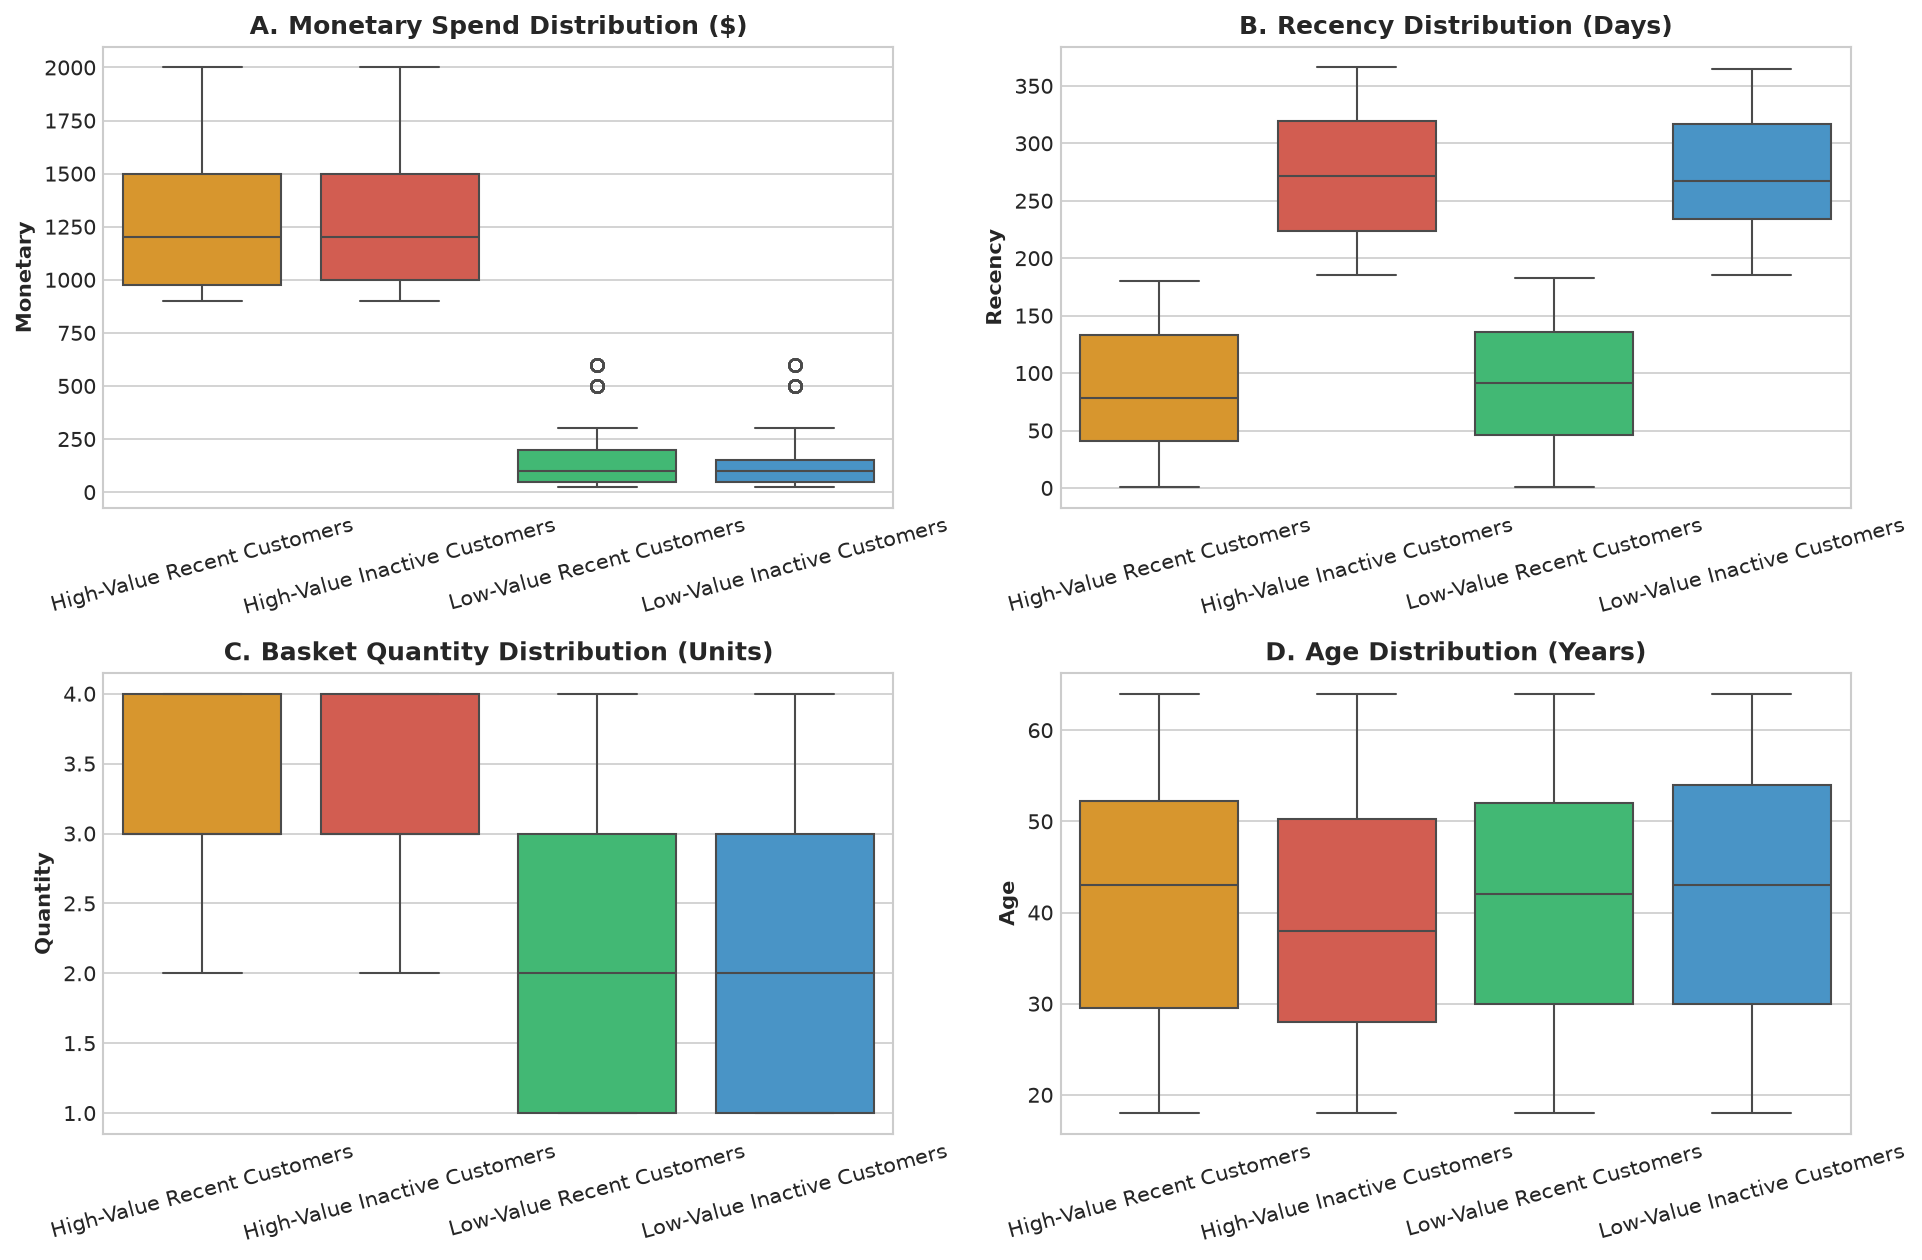

In [19]:
# Boxplots of metrics across segments
fig, axs = plt.subplots(2, 2, figsize=(13, 8.5))
order_names = ['High-Value Recent Customers', 'High-Value Inactive Customers', 'Low-Value Recent Customers', 'Low-Value Inactive Customers']
palette_list = [cluster_colors[3], cluster_colors[0], cluster_colors[1], cluster_colors[2]]

sns.boxplot(data=customer_df, x='Segment_Name', y='Monetary', ax=axs[0, 0], order=order_names, palette=palette_list, hue='Segment_Name', legend=False)
axs[0, 0].set_title('A. Monetary Spend Distribution ($)')
axs[0, 0].set_xlabel('')
axs[0, 0].tick_params(axis='x', rotation=15)

sns.boxplot(data=customer_df, x='Segment_Name', y='Recency', ax=axs[0, 1], order=order_names, palette=palette_list, hue='Segment_Name', legend=False)
axs[0, 1].set_title('B. Recency Distribution (Days)')
axs[0, 1].set_xlabel('')
axs[0, 1].tick_params(axis='x', rotation=15)

sns.boxplot(data=customer_df, x='Segment_Name', y='Quantity', ax=axs[1, 0], order=order_names, palette=palette_list, hue='Segment_Name', legend=False)
axs[1, 0].set_title('C. Basket Quantity Distribution (Units)')
axs[1, 0].set_xlabel('')
axs[1, 0].tick_params(axis='x', rotation=15)

sns.boxplot(data=customer_df, x='Segment_Name', y='Age', ax=axs[1, 1], order=order_names, palette=palette_list, hue='Segment_Name', legend=False)
axs[1, 1].set_title('D. Age Distribution (Years)')
axs[1, 1].set_xlabel('')
axs[1, 1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../outputs/figures/07_cluster_metric_boxplots.png', bbox_inches='tight')
plt.show()


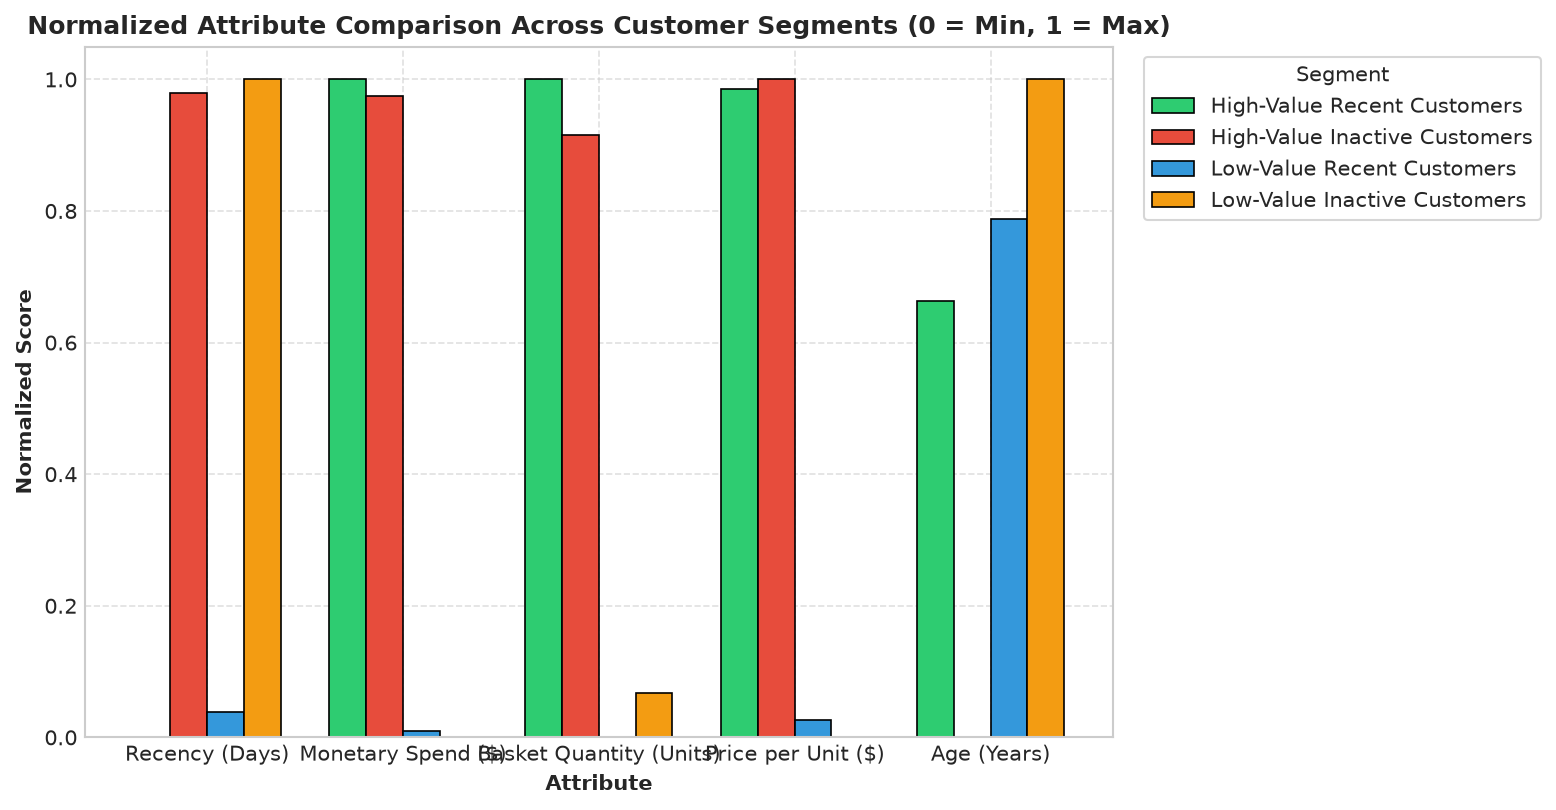

In [20]:
# Multi-attribute comparison
norm_metrics = customer_df.groupby('Segment_Name')[['Recency', 'Monetary', 'Quantity', 'Avg_Price_Per_Unit', 'Age']].mean().loc[order_names]
norm_df = (norm_metrics - norm_metrics.min()) / (norm_metrics.max() - norm_metrics.min())

fig, ax = plt.subplots(figsize=(10.5, 5.5))
norm_df.T.plot(kind='bar', ax=ax, width=0.75, color=palette_list, edgecolor='black', linewidth=0.8)
ax.set_title('Normalized Attribute Comparison Across Customer Segments (0 = Min, 1 = Max)')
ax.set_ylabel('Normalized Score')
ax.set_xlabel('Attribute')
ax.set_xticklabels(['Recency (Days)', 'Monetary Spend ($)', 'Basket Quantity (Units)', 'Price per Unit ($)', 'Age (Years)'], rotation=0)
ax.legend(title='Segment', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('../outputs/figures/08_cluster_profile_radar.png', bbox_inches='tight')
plt.show()


## 21 — Segment Interpretation

Based on empirical clustering statistics, the four distinct customer segments are defined as:

| Segment Name | Cluster ID | Customer Count (% Share) | Total Revenue (% Share) | Avg Recency | Avg Spend | Key Empirical Profile |
|---|---|---|---|---|---|---|
| **High-Value Recent Customers** | `Cluster 3` | 124 (12.4%) | \$162,900 (35.72%) | 84.9 days | \$1,313.71 | High-spend buyers who made a purchase recently (1-180 days ago) with high basket sizes (3.25 units avg). |
| **High-Value Inactive Customers** | `Cluster 0` | 140 (14.0%) | \$179,700 (39.41%) | 270.5 days | \$1,283.57 | High-spend buyers who purchased 6–12 months ago (185-366 days ago) and have no additional purchase recorded in the available dataset. |
| **Low-Value Recent Customers** | `Cluster 1` | 370 (37.0%) | \$59,120 (12.96%) | 92.1 days | \$159.78 | Recent purchasers who bought low-to-mid ticket items (2.23 units avg, \$100 median spend). |
| **Low-Value Inactive Customers** | `Cluster 2` | 366 (36.6%) | \$54,280 (11.90%) | 274.6 days | \$148.31 | Budget buyers whose purchase occurred 6–12 months ago with no additional purchase recorded in the available dataset. |

## 22 — Actionable Marketing Recommendations

Following the empirical findings, marketing recommendations are structured under the rigorous `Finding → Business Implication → Recommended Action` framework:

---

### 1. High-Value Recent Customers — *Cluster 3 (12.4% Cust, 35.7% Rev)*
- **Finding:** Customers in this cluster exhibit the highest average spend (\$1,313.71) and shortest recency (84.9 days), purchasing large multi-item baskets (3.25 units avg).
- **Business Implication:** These are the business's most valuable recent buyers; maintaining their engagement is critical to protecting recurring revenue.
- **Recommended Action:**
  - Enroll into a premium VIP loyalty program.
  - Provide early access to new product catalog drops and high-ticket electronics/clothing.
  - Assign dedicated customer support channels and personalized post-purchase appreciation.

---

### 2. High-Value Inactive Customers — *Cluster 0 (14.0% Cust, 39.4% Rev)*
- **Finding:** Customers spent high amounts (\$1,283.57 avg) but have an average recency of 270.5 days (median 271.5 days), having no additional purchase recorded in the available dataset. This single cluster accounts for **\$179,700 (39.41%) of all historical revenue**.
- **Business Implication:** Because this cohort accounts for the largest historical revenue contribution, continued inactivity could represent a significant revenue risk.
- **Recommended Action:**
  - Launch targeted re-engagement communications highlighting new premium products.
  - Deploy category-aligned reactivation incentives in their preferred product categories.
  - Conduct brief satisfaction surveys to gather feedback on their purchasing experience.

---

### 3. Low-Value Recent Customers — *Cluster 1 (37.0% Cust, 13.0% Rev)*
- **Finding:** Largest active group (370 customers) who bought recently (92.1 days avg), but with modest average basket spend (\$159.78).
- **Business Implication:** High recent engagement provides an opportunity for average order value (AOV) expansion.
- **Recommended Action:**
  - Deploy cross-selling and bundling recommendations (e.g., complementary beauty and clothing accessories).
  - Implement minimum spend thresholds for free shipping to incentivize adding extra units to the basket.
  - Offer multi-item promotions across categories.

---

### 4. Low-Value Inactive Customers — *Cluster 2 (36.6% Cust, 11.9% Rev)*
- **Finding:** 366 customers who spent an average of \$148.31 and have an average recency of 274.6 days, with no additional purchase recorded in the available dataset.
- **Business Implication:** Low customer value combined with extended inactivity makes high-cost outreach cost-ineffective.
- **Recommended Action:**
  - Target through low-cost automated email reactivation workflows.
  - Re-engage during broad seasonal marquee retail campaigns (e.g., annual clearance events).
  - Suppress unengaged contacts after standard campaign cycles to maintain high deliverability.

## 23 — Conclusion

This customer segmentation analysis successfully partitioned 1,000 retail customers into 4 statistically distinct, business-actionable segments using standardized Recency and Monetary behavioral features.

### Key Takeaways:
1. **Revenue Asymmetry:** 26.4% of customers generate 75.1% of revenue, highlighting the disproportionate importance of high-value customer retention.
2. **Dormancy Intervention Focus:** \$179,700 in historical revenue sits in the "High-Value Inactive Customers" segment, where continued inactivity could represent a significant revenue risk.
3. **Data-Driven Precision:** Replacing generic marketing with segment-aligned campaigns enables optimal resource allocation across loyalty, re-engagement, upselling, and automated workflows.

## 24 — Limitations

1. **Single Transaction per Customer:** The dataset contains exactly 1 transaction per customer ($F=1$), meaning repeat purchase frequency and traditional multi-period CLV cannot be empirically calculated.
2. **1-Year Time Window:** Data spans exactly 365 days (2023-01-01 to 2024-01-01), precluding multi-year cohort retention modeling.
3. **Broad Product Categories:** Product classification is limited to 3 broad categories (`Clothing`, `Electronics`, `Beauty`) without SKU-level hierarchy.
4. **Observed Data Scope:** Inactivity is measured strictly by chronological Recency within the dataset observation window rather than explicit account closure.

## 25 — Reproducibility & Environment

To reproduce this analysis completely from scratch:
1. Clone the repository and navigate to `DataAnalytics-Level1-Task2-CustomerSegmentation/notebooks/`.
2. Ensure Python 3.10+ virtual environment is active with dependencies: `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`, `jupyter`.
3. Run the notebook top-to-bottom (`Kernel -> Restart and Run All Cells`).
4. All figures will be regenerated in `../outputs/figures/` and processed tables in `../outputs/tables/` and `../data/processed/`.

In [21]:
print("=== VERIFICATION & REPRODUCIBILITY AUDIT ===")
print("All 25 sections executed cleanly.")
print(f"Total Customers Processed: {len(customer_df)}")
print(f"Total Revenue Verified: ${customer_df['Monetary'].sum():,.2f}")
print(f"Cluster Assignment Counts:\n{customer_df['Segment_Name'].value_counts()}")


=== VERIFICATION & REPRODUCIBILITY AUDIT ===
All 25 sections executed cleanly.
Total Customers Processed: 1000
Total Revenue Verified: $456,000.00
Cluster Assignment Counts:
Segment_Name
Low-Value Recent Customers       370
Low-Value Inactive Customers     366
High-Value Inactive Customers    140
High-Value Recent Customers      124
Name: count, dtype: int64
